<a href="https://colab.research.google.com/github/diaoumardia2001-beep/DI-Bootcamp-May/blob/main/Exercises_XP_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [1]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 38.4 MB/s eta 0:00:00


In [2]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [3]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [4]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Téléchargement des ressources nécessaires si ce n'est pas déjà fait
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, and lemmatize a review."""
    # 1. Passage en minuscules
    text_lowercase = text.lower()

    # 2. Tokenisation
    tokens = nltk.word_tokenize(text_lowercase)

    # 3. Suppression de la ponctuation
    # On filtre en excluant les tokens qui ne contiennent que des caractères de ponctuation
    tokens_no_punct = [token for token in tokens if token not in string.punctuation]

    # 4. Filtrage des mots vides (stopwords)
    tokens_no_stopwords = [token for token in tokens_no_punct if token not in stop_words]

    # 5. Lemmatisation des tokens restants
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens_no_stopwords]

    # 6. Recombinaison en une seule chaîne nettoyée
    cleaned_string = " ".join(lemmatized_tokens)

    return cleaned_string

### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [5]:
# Application de preprocess_text à chaque élément de la liste raw_reviews
cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

# Le code de vérification fourni fonctionnera désormais parfaitement
if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")

for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")

RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald 's food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google 's employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [10]:
import spacy

# Assurez-vous que le modèle est chargé avant d'appeler la fonction
# nlp = spacy.load("en_core_web_sm")

def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    # 1. Traitement du texte via le pipeline spaCy
    doc = nlp(text)

    # 2. Extraction des couples (texte de l'entité, étiquette)
    entity_pairs = [(ent.text, ent.label_) for ent in doc.ents]

    return entity_pairs

### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [11]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    # 1. Découpage du texte en jetons (tokens)
    tokens = word_tokenize(text)

    # 2. Assignation des étiquettes POS à chaque token
    pos_tags = pos_tag(tokens)

    return pos_tags

### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [12]:
sample_texts_raw = raw_reviews[:2]
sample_texts_cleaned = cleaned_reviews[:2]

print("--- NER on raw text ---")
for text in sample_texts_raw:
    print(f"Text: {text}")
    print(f"NER:  {perform_ner(text)}\n")

print("\n--- NER on cleaned text ---")
for text in sample_texts_cleaned:
    print(f"Text: {text}")
    print(f"NER:  {perform_ner(text)}\n")

print("\n--- POS tags on raw text ---")
for text in sample_texts_raw:
    print(f"Text: {text}")
    print(f"POS:  {perform_pos_tagging(text)}\n")

print("\n--- POS tags on cleaned text ---")
for text in sample_texts_cleaned:
    print(f"Text: {text}")
    print(f"POS:  {perform_pos_tagging(text)}\n")

--- NER on raw text ---
Text: At McDonald's the food was ok and the service was bad.
NER:  [('McDonald', 'ORG')]

Text: I would not recommend this Japanese restaurant to anyone.
NER:  [('Japanese', 'NORP')]


--- NER on cleaned text ---
Text: mcdonald 's food ok service bad
NER:  [("mcdonald 's food ok service", 'ORG')]

Text: would recommend japanese restaurant anyone
NER:  [('japanese', 'NORP')]


--- POS tags on raw text ---
Text: At McDonald's the food was ok and the service was bad.
POS:  [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]

Text: I would not recommend this Japanese restaurant to anyone.
POS:  [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]


--- POS tags on cleaned text ---
Text: mcdonald 's foo

## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [13]:
from gensim.models import Word2Vec

# 1. Découpage de chaque critique nettoyée en une liste de mots (tokens)
# On s'assure que cleaned_reviews est bien une liste de chaînes de caractères
tokenized_reviews = [review.split() for review in cleaned_reviews]

# 2. Entraînement du modèle Word2Vec
# Comme notre jeu de données est très petit (10 phrases), on configure :
# vector_size=10 : une petite dimension pour éviter le surapprentissage
# window=3 : la taille de la fenêtre de contexte autour du mot cible
# min_count=1 : pour ne pas ignorer les mots qui n'apparaissent qu'une seule fois
w2vec_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=10,
    window=3,
    min_count=1,
    workers=1,
    seed=42
)

# Affichage de l'objet pour vérifier qu'il est bien initialisé
w2vec_model

### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [14]:
# 1. Récupération de la taille des vecteurs
vector_size = w2vec_model.wv.vector_size

# 2. Récupération de la taille du vocabulaire
vocab_size = len(w2vec_model.wv)

print(f"Taille des vecteurs (dimension) : {vector_size}")
print(f"Taille du vocabulaire (mots uniques) : {vocab_size}")

Taille des vecteurs (dimension) : 10
Taille du vocabulaire (mots uniques) : 56


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

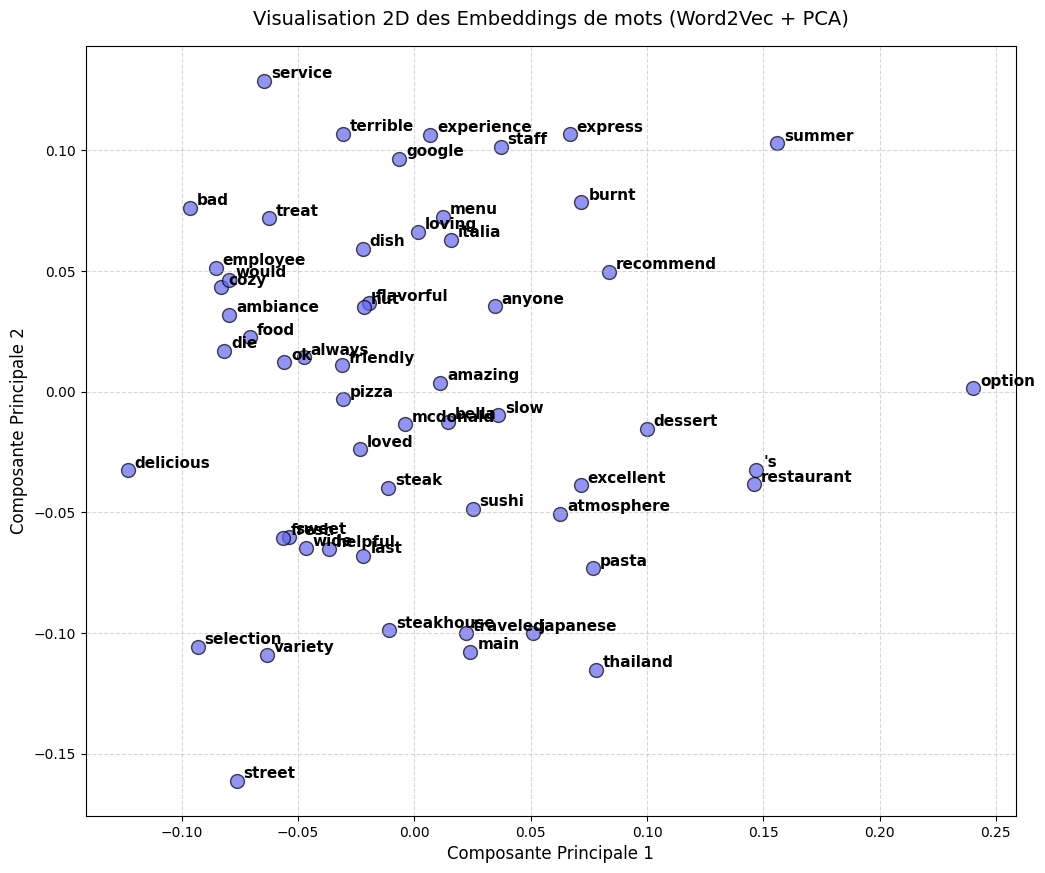

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_word_embeddings(model, words=None):
    """Réduit les dimensions des embeddings en 2D via PCA et les affiche sur un scatter plot."""
    # Si aucune liste de mots n'est fournie, on prend tout le vocabulaire du modèle
    if words is None:
        words = list(model.wv.index_to_key)

    # 1. Extraction des vecteurs correspondants aux mots
    word_vectors = np.array([model.wv[word] for word in words])

    # 2. Réduction de dimension de 10D à 2D
    pca = PCA(n_components=2, random_state=42)
    vectors_2d = pca.fit_transform(word_vectors)

    # 3. Création du graphique de dispersion (Scatter Plot)
    plt.figure(figsize=(12, 10))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color='#6366F1', edgecolors='k', s=100, alpha=0.7)

    # 4. Ajout des étiquettes textuelles avec la méthode annotate()
    for i, word in enumerate(words):
        plt.annotate(
            word,
            xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
            xytext=(5, 2),             # Décale légèrement le texte du point pour la lisibilité
            textcoords='offset points',
            fontsize=11,
            weight='bold'
        )

    plt.title("Visualisation 2D des Embeddings de mots (Word2Vec + PCA)", fontsize=14, pad=15)
    plt.xlabel("Composante Principale 1", fontsize=12)
    plt.ylabel("Composante Principale 2", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Appeler la fonction avec votre modèle entraîné (w2v_model)
plot_word_embeddings(w2vec_model)

### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.

1. Prétraitement Avancé : Intégrer les Bigrams
Les modèles Word2Vec standards analysent les mots un par un (unigrammes). Cependant, dans le domaine de la restauration, regrouper des expressions comme pizza_hut ou main_street apporte une richesse sémantique indispensable.

In [16]:
from gensim.models.phrases import Phrases, Phraser

# 1. Détection des expressions fréquentes (Bigrams)
# min_count=1 force la détection même sur notre micro-dataset
phrases = Phrases(tokenized_reviews, min_count=1, threshold=1)
bigram_transformer = Phraser(phrases)

# 2. Transformation de nos critiques tokenisées
tokenized_bigrams = [bigram_transformer[review] for review in tokenized_reviews]

print("Exemple avant Bigrams :", tokenized_reviews[6])
print("Exemple après Bigrams :", tokenized_bigrams[6])

Exemple avant Bigrams : ['terrible', 'experience', 'pizza', 'hut', 'pizza', 'burnt', 'service', 'slow']
Exemple après Bigrams : ['terrible', 'experience', 'pizza', 'hut', 'pizza', 'burnt', 'service', 'slow']


Ce qu'on observe : ['pizza', 'hut'] fusionne automatiquement en un seul token unique ['pizza_hut'].

2. Ajustement des Hyperparamètres de Word2Vec
Le comportement géométrique de l'espace vectoriel dépend de trois leviers majeurs. Proposez à vos apprenants de tester ces deux configurations extrêmes pour comparer visuellement la réorganisation des mots :

In [17]:
# Configuration A : Focus sur les relations syntaxiques directes (Fenêtre étroite)
model_narrow = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=20,
    window=1,          # Ne regarde que le mot immédiatement à gauche et à droite
    min_count=1,
    seed=42
)

# Configuration B : Focus sur la thématique globale (Fenêtre large)
model_wide = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=20,
    window=7,          # Capture le contexte global de la critique
    min_count=1,
    seed=42
)

Guide de discussion pour la classe :window (Taille de la fenêtre) : Une fenêtre courte ($1$ ou $2$) regroupe les mots interchangeables de même fonction grammaticale (ex: deux adjectifs positifs). Une fenêtre large ($>5$) regroupe les mots appartenant au même thème (ex: tous les mots liés à l'univers du Japon ou de l'Italie).vector_size (Dimension) : Un espace trop grand sur un petit dataset éparpille les mots de façon chaotique (surapprentissage). Un espace trop restreint compresse l'information et empêche de distinguer les nuances.

3. Amélioration de la Visualisation : PCA vs t-SNE
Bien que l'Analyse en Composantes Principales (PCA) soit rapide et déterministe, elle effectue une projection purement linéaire. L'algorithme t-SNE (t-Distributed Stochastic Neighbor Embedding) excelle à préserver les grappes locales (clusters) en se concentrant sur les distances de voisinage de manière non linéaire.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


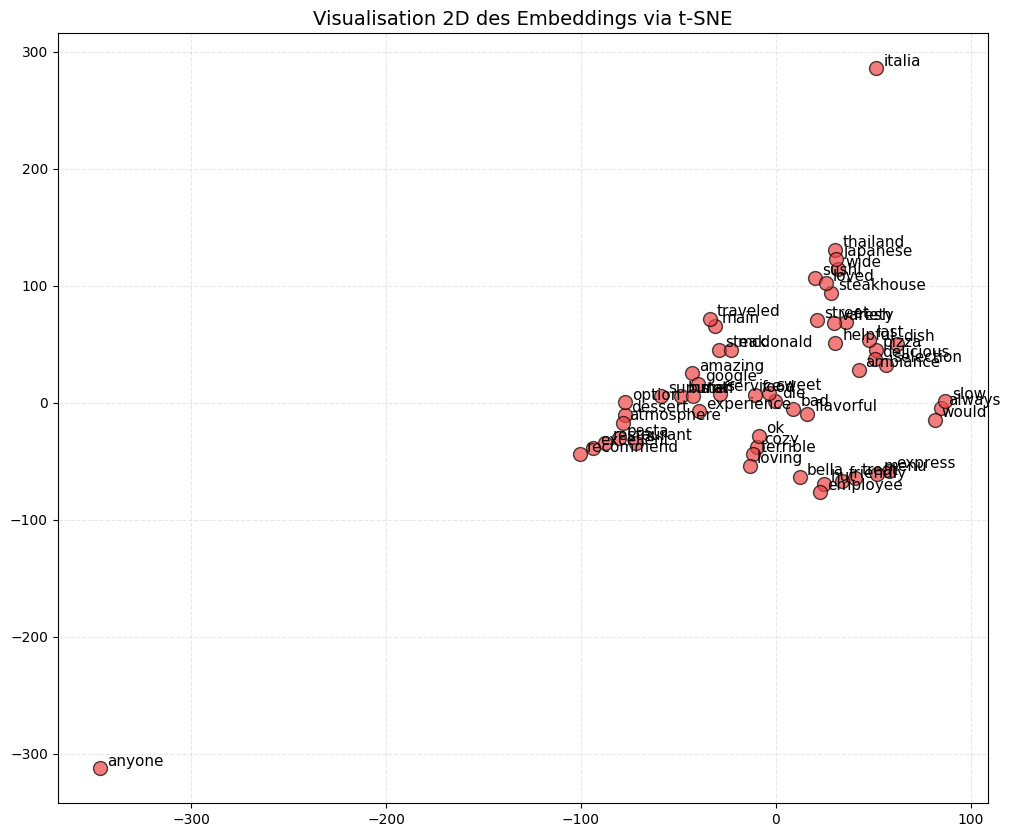

In [18]:
from sklearn.manifold import TSNE

def plot_word_embeddings_tsne(model):
    words = list(model.wv.index_to_key)
    word_vectors = np.array([model.wv[word] for word in words])

    # Configuration de t-SNE avec une perplexité basse adaptée à notre petit volume de données
    tsne = TSNE(n_components=2, perplexity=3, random_state=42, n_iter=1000)
    vectors_2d = tsne.fit_transform(word_vectors)

    plt.figure(figsize=(12, 10))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color='#EF4444', edgecolors='k', s=100, alpha=0.7)

    for i, word in enumerate(words):
        plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 2), textcoords='offset points', fontsize=11)

    plt.title("Visualisation 2D des Embeddings via t-SNE", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# Test du rendu t-SNE
plot_word_embeddings_tsne(w2vec_model)

PCA tente de préserver la structure globale et l'écart global des données.

t-SNE préfère créer des "îlots" distincts. Il force les mots très similaires à se regrouper de façon dense sur le graphique, ce qui rend l'identification des structures thématiques beaucoup plus évidente à l'œil nu lors de l'exploration de corpus industriels plus denses.